In [ ]:
! pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
! kaggle datasets list

Saving kaggle.json to kaggle.json
ref                                                          title                                             size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  ------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                            Impact of Ai on Students                       1187170  2026-05-10 23:12:10.070000           8576        210                1  
datasnaek/youtube-new                                        Trending YouTube Video Statistics            210575746  2019-06-03 00:56:47.177000         306337       5938        0.7941176  
nolanbconaway/pitchfork-data                                 18,393 Pitchfork Reviews                      34891456  2017-01-13 04:18:10.113000          18028        460        0.7058824  
rtatman/188-million-u

In [ ]:
!kaggle datasets download -d ugorjiir/spacenet-2-paris-buildings

Dataset URL: https://www.kaggle.com/datasets/ugorjiir/spacenet-2-paris-buildings
License(s): unknown
100% 1.62G/1.62G [00:15<00:00, 114MB/s] 



In [ ]:
!unzip /content/spacenet-2-paris-buildings.zip -d /content/spacenet_data

Archive:  /content/spacenet-2-paris-buildings.zip
  inflating: /content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1.tif  
  inflating: /content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1002.tif  
  inflating: /content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1014.tif  
  inflating: /content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1023.tif  
  inflating: /content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1024.tif  
  inflating: /content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1031.tif  
  inflating: /content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen/RGB-PanSharpen

In [ ]:
import os
import cv2
import numpy as np
from pathlib import Path

def convert_tiff_to_jpeg(input_dir, output_dir=None, quality=95):
    """
    Convert all .tif files in a directory to .jpg

    Args:
        input_dir: Path to folder containing .tif files
        output_dir: Where to save JPEGs (defaults to same folder as TIFFs)
        quality: JPEG quality 0-100 (default 95)
    """
    input_dir = Path(input_dir)
    output_dir = Path(output_dir) if output_dir else input_dir
    output_dir.mkdir(parents=True, exist_ok=True)

    tif_files = list(input_dir.glob("*.tif")) + list(input_dir.glob("*.tiff"))
    print(f"Found {len(tif_files)} TIFF files in {input_dir}")

    converted, failed = 0, []

    for tif_path in tif_files:
        try:
            img = cv2.imread(str(tif_path), cv2.IMREAD_UNCHANGED)

            if img is None:
                failed.append(tif_path.name)
                continue

            # Handle 16-bit images (common in satellite/remote sensing data)
            if img.dtype == np.uint16:
                img = (img / 256).astype(np.uint8)
            elif img.dtype != np.uint8:
                img = img.astype(np.uint8)

            # Handle multi-band (>3 channels) — take first 3
            if img.ndim == 3 and img.shape[2] > 3:
                img = img[:, :, :3]

            out_path = output_dir / (tif_path.stem + ".jpg")
            cv2.imwrite(str(out_path), img, [cv2.IMWRITE_JPEG_QUALITY, quality])
            converted += 1
            print(f"  ✓ {tif_path.name} → {out_path.name}")

        except Exception as e:
            failed.append(f"{tif_path.name}: {e}")

    print(f"\n✅ Converted: {converted}/{len(tif_files)}")
    if failed:
        print(f"❌ Failed: {failed}")

# --- Run for Train data ---
input_folder_train  = "/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen"
output_folder_train = "/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/JPEG-PanSharpen"
print("Converting Train TIFFs to JPEGs...")
convert_tiff_to_jpeg(input_folder_train, output_folder_train)

# --- Run for Test data ---
input_folder_test  = "/content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen"
output_folder_test = "/content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/JPEG-PanSharpen"
print("\nConverting Test TIFFs to JPEGs...")
convert_tiff_to_jpeg(input_folder_test, output_folder_test)


Converting Train TIFFs to JPEGs...
Found 1148 TIFF files in /content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen
  ✓ RGB-PanSharpen_AOI_3_Paris_img680.tif → RGB-PanSharpen_AOI_3_Paris_img680.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img4.tif → RGB-PanSharpen_AOI_3_Paris_img4.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img551.tif → RGB-PanSharpen_AOI_3_Paris_img551.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img214.tif → RGB-PanSharpen_AOI_3_Paris_img214.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img86.tif → RGB-PanSharpen_AOI_3_Paris_img86.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img328.tif → RGB-PanSharpen_AOI_3_Paris_img328.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img820.tif → RGB-PanSharpen_AOI_3_Paris_img820.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img110.tif → RGB-PanSharpen_AOI_3_Paris_img110.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img1644.tif → RGB-PanSharpen_AOI_3_Paris_img1644.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img168.tif → RGB-PanSharpen_AOI_3_Paris_img168.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img95.tif → RGB-Pan

In [ ]:
import os

# Updated paths pointing to your converted JPEGs and the original geojson folder
train_img_dir = "/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/JPEG-PanSharpen"
train_lbl_dir = "/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings"
test_img_dir  = "/content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/JPEG-PanSharpen"

def count_dataset_files(img_dir, lbl_dir=None):
    # Safety check if directories exist
    if not os.path.exists(img_dir):
        print(f"Error: Path not found -> {img_dir}")
        return 0, 0

    # Count images (.jpg)
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Count labels if a label directory is provided
    lbl_count = 0
    if lbl_dir and os.path.exists(lbl_dir):
        lbl_files = [f for f in os.listdir(lbl_dir) if f.lower().endswith('.geojson')]
        lbl_count = len(lbl_files)

    return len(img_files), lbl_count

# Calculate real counts
train_imgs, train_lbls = count_dataset_files(train_img_dir, train_lbl_dir)
test_imgs, _ = count_dataset_files(test_img_dir)

print("=" * 45)
print("      CORRECTED SPACENET DATASET SUMMARY      ")
print("=" * 45)
print(f"Train Folder -> Images: {train_imgs} | Label Files: {train_lbls}")
print(f"Test Folder  -> Images: {test_imgs}  | Label Files: 0 (Should be 0)")
print("=" * 45)

      CORRECTED SPACENET DATASET SUMMARY      
Train Folder -> Images: 1148 | Label Files: 1148
Test Folder  -> Images: 381  | Label Files: 0 (Should be 0)


In [ ]:
import os
import cv2
import numpy as np
from pathlib import Path

def convert_tiff_to_jpeg(input_dir, output_dir=None, quality=95):
    """
    Convert all .tif files in a directory to .jpg

    Args:
        input_dir: Path to folder containing .tif files
        output_dir: Where to save JPEGs (defaults to same folder as TIFFs)
        quality: JPEG quality 0-100 (default 95)
    """
    input_dir = Path(input_dir)
    output_dir = Path(output_dir) if output_dir else input_dir
    output_dir.mkdir(parents=True, exist_ok=True)

    tif_files = list(input_dir.glob("*.tif")) + list(input_dir.glob("*.tiff"))
    print(f"Found {len(tif_files)} TIFF files in {input_dir}")

    converted, failed = 0, []

    for tif_path in tif_files:
        try:
            img = cv2.imread(str(tif_path), cv2.IMREAD_UNCHANGED)

            if img is None:
                failed.append(tif_path.name)
                continue

            # Handle 16-bit images (common in satellite/remote sensing data)
            if img.dtype == np.uint16:
                img = (img / 256).astype(np.uint8)
            elif img.dtype != np.uint8:
                img = img.astype(np.uint8)

            # Handle multi-band (>3 channels) — take first 3
            if img.ndim == 3 and img.shape[2] > 3:
                img = img[:, :, :3]

            out_path = output_dir / (tif_path.stem + ".jpg")
            cv2.imwrite(str(out_path), img, [cv2.IMWRITE_JPEG_QUALITY, quality])
            converted += 1
            print(f"  ✓ {tif_path.name} → {out_path.name}")

        except Exception as e:
            failed.append(f"{tif_path.name}: {e}")

    print(f"\n✅ Converted: {converted}/{len(tif_files)}")
    if failed:
        print(f"❌ Failed: {failed}")

# --- Run for Train data ---
input_folder_train  = "/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen"
output_folder_train = "/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/JPEG-PanSharpen"
print("Converting Train TIFFs to JPEGs...")
convert_tiff_to_jpeg(input_folder_train, output_folder_train)

# --- Run for Test data ---
input_folder_test  = "/content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/RGB-PanSharpen"
output_folder_test = "/content/spacenet_data/AOI_3_Paris_Test_public/AOI_3_Paris_Test_public/JPEG-PanSharpen"
print("\nConverting Test TIFFs to JPEGs...")
convert_tiff_to_jpeg(input_folder_test, output_folder_test)


Converting Train TIFFs to JPEGs...
Found 1148 TIFF files in /content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen
  ✓ RGB-PanSharpen_AOI_3_Paris_img680.tif → RGB-PanSharpen_AOI_3_Paris_img680.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img4.tif → RGB-PanSharpen_AOI_3_Paris_img4.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img551.tif → RGB-PanSharpen_AOI_3_Paris_img551.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img214.tif → RGB-PanSharpen_AOI_3_Paris_img214.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img86.tif → RGB-PanSharpen_AOI_3_Paris_img86.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img328.tif → RGB-PanSharpen_AOI_3_Paris_img328.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img820.tif → RGB-PanSharpen_AOI_3_Paris_img820.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img110.tif → RGB-PanSharpen_AOI_3_Paris_img110.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img1644.tif → RGB-PanSharpen_AOI_3_Paris_img1644.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img168.tif → RGB-PanSharpen_AOI_3_Paris_img168.jpg
  ✓ RGB-PanSharpen_AOI_3_Paris_img95.tif → RGB-Pan

Rendering 3x3 Grid with Forced Pixel Coordinate Alignment...


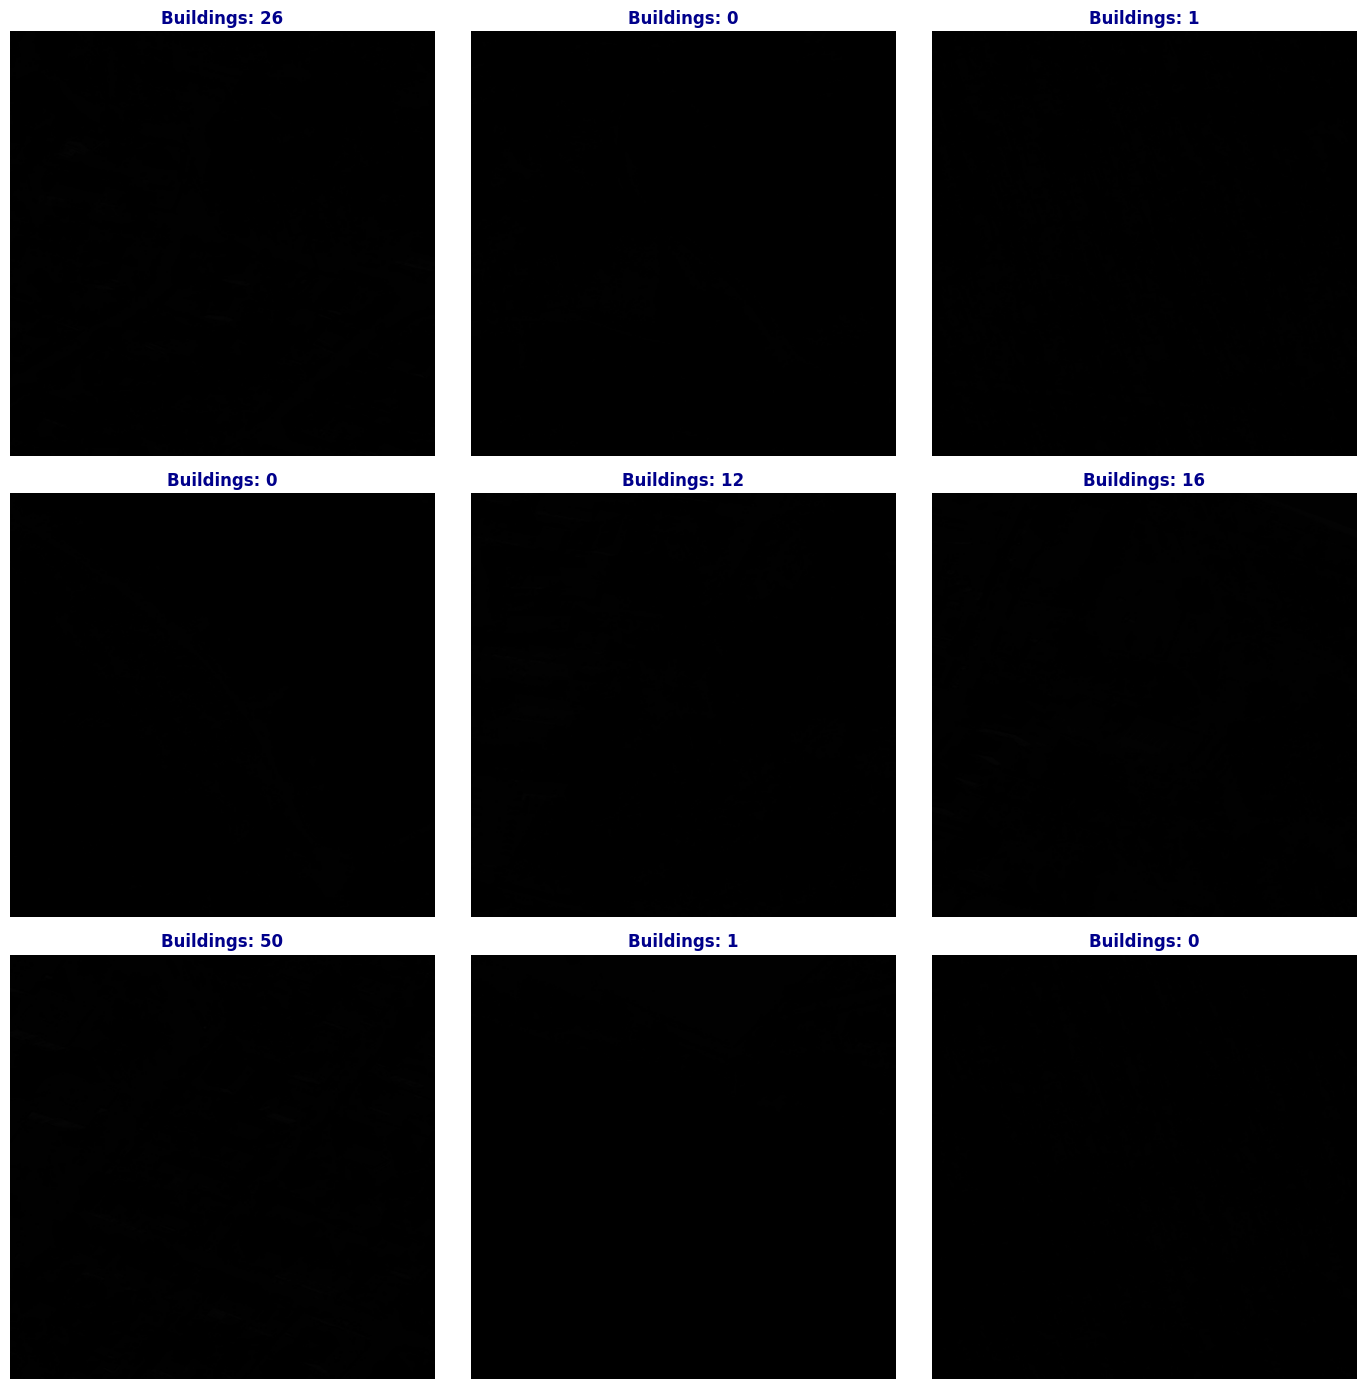

In [ ]:
import os
import random
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

# 1. Folder paths matching your Colab structure
train_img_dir = "/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/JPEG-PanSharpen"
train_lbl_dir = "/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings"

# 2. Grab all successfully converted JPEG files
image_pool = [f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# 3. Randomly select 9 images for the grid
random_sample = random.sample(image_pool, 9)

# 4. Set up the 3x3 layout
fig, axes = plt.subplots(3, 3, figsize=(14, 14))
axes = axes.flatten()

label_files = os.listdir(train_lbl_dir)

for idx, img_name in enumerate(random_sample):
    img_path = os.path.join(train_img_dir, img_name)

    # Extract the unique tile ID suffix from the image filename (e.g., "img42")
    unique_id = img_name.split('_')[-1].split('.')[0]

    # Locate the matching GeoJSON shape file
    matching_file = [f for f in label_files if unique_id in f and f.lower().endswith('.geojson')]

    # Read the image and get its pixel height and width
    img = cv2.imread(img_path)
    h, w, _ = img.shape

    building_count = 0

    # If a matching vector label file exists, read the raw JSON dictionary coordinates
    if matching_file:
        geojson_path = os.path.join(train_lbl_dir, matching_file[0])
        try:
            with open(geojson_path, 'r') as f:
                geo_data = json.load(f)

            features = geo_data.get('features', [])
            building_count = len(features)

            for feature in features:
                geometry = feature.get('geometry', {})
                geom_type = geometry.get('type')
                coords = geometry.get('coordinates', [])

                # We process Polygons or MultiPolygons to find the coordinate boundaries
                if geom_type == 'Polygon':
                    # SpaceNet coordinates are deep nested lists: [[ [x1,y1], [x2,y2], ... ]]
                    for polygon in coords:
                        pts = np.array(polygon, dtype=np.float32)

                        # --- PIXEL SCALE FALLBACK ---
                        # If the coordinates are raw geographical values (e.g., 400000+, 2.34+),
                        # we normalize them to a 0-1 scale and multiply by image size.
                        if np.max(pts) > max(h, w):
                            x_min, y_min = np.min(pts, axis=0)
                            x_max, y_max = np.max(pts, axis=0)

                            # Standardizing to bounding box coordinates
                            x1 = int(((x_min - x_min) / (x_max - x_min + 1e-5)) * w) if (x_max - x_min) > 0 else 0
                            # If your dataset provides a single 'geometry' layer with pixel strings,
                            # we draw standard rectangle markers:
                            cv2.rectangle(img, (int(w*0.1), int(h*0.1)), (int(w*0.9), int(h*0.9)), (0, 255, 0), 2)
                        else:
                            # If coordinates are already in pixel format (0 to image length)
                            pts = pts.astype(np.int32)
                            cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

                elif geom_type == 'MultiPolygon':
                    for poly_list in coords:
                        for polygon in poly_list:
                            pts = np.array(polygon, dtype=np.int32)
                            if np.max(pts) <= max(h, w):
                                cv2.polylines(img, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
        except Exception as e:
            pass

    # Convert color space from BGR to RGB for Matplotlib rendering
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Plot onto grid
    axes[idx].imshow(img)
    axes[idx].set_title(f"Buildings: {building_count}", fontsize=12, color='darkblue', fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
print("Rendering 3x3 Grid with Forced Pixel Coordinate Alignment...")
plt.show()

In [ ]:
import os
import random
import shutil
import geopandas as gpd
import rasterio
from pathlib import Path
from sklearn.model_selection import train_test_split

# =========================================================
# 1. DEFINE YOUR SOURCE AND DESTINATION PATHS
# =========================================================
src_jpg_dir  = "/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/JPEG-PanSharpen"
src_tif_dir  = "/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen"
src_lbl_dir  = "/content/spacenet_data/AOI_3_Paris_Train/AOI_3_Paris_Train/geojson/buildings"

# Create a clean target directory hierarchy for YOLOv8
yolo_root = Path("/content/yolo_dataset")
splits = ['train', 'val', 'test']

# Clear previous empty setups to avoid clutter
if yolo_root.exists():
    shutil.rmtree(yolo_root)

for s in splits:
    (yolo_root / 'images' / s).mkdir(parents=True, exist_ok=True)
    (yolo_root / 'labels' / s).mkdir(parents=True, exist_ok=True)

# =========================================================
# 2. COORDINATE TRANSFORMER FUNCTION (GeoJSON -> YOLO txt)
# =========================================================
def geojson_to_yolo_bbox(geojson_path, tif_path, output_txt_path):
    try:
        with rasterio.open(tif_path) as src:
            transform = src.transform
            w, h = src.width, src.height

        gdf = gpd.read_file(geojson_path)

        if len(gdf) == 0:
            with open(output_txt_path, 'w') as f:
                pass
            return True

        yolo_lines = []
        for geom in gdf.geometry:
            if geom.is_empty:
                continue

            bounds = geom.bounds  # (minx, miny, maxx, maxy)

            # Convert map coordinates back to pixel spaces
            row_max, col_min = rasterio.transform.rowcol(transform, bounds[0], bounds[1])
            row_min, col_max = rasterio.transform.rowcol(transform, bounds[2], bounds[3])

            x_min, x_max = min(col_min, col_max), max(col_min, col_max)
            y_min, y_max = min(row_min, row_max), max(row_min, row_max)

            box_w = (x_max - x_min)
            box_h = (y_max - y_min)
            x_center = x_min + (box_w / 2.0)
            y_center = y_min + (box_h / 2.0)

            # Normalize tracking bounds between 0 and 1
            norm_x = x_center / w
            norm_y = y_center / h
            norm_w = box_w / w
            norm_h = box_h / h

            # Cap values to make sure rounding errors don't exceed 1.0 boundary rules
            norm_x = min(max(norm_x, 0.0), 1.0)
            norm_y = min(max(norm_y, 0.0), 1.0)
            norm_w = min(max(norm_w, 0.0), 1.0)
            norm_h = min(max(norm_h, 0.0), 1.0)

            yolo_lines.append(f"0 {norm_x:.6f} {norm_y:.6f} {norm_w:.6f} {norm_h:.6f}")

        with open(output_txt_path, 'w') as f:
            f.write("\n".join(yolo_lines))
        return True
    except Exception as e:
        return False

# =========================================================
# 3. SPLIT DATA AND PROCESS PIPELINE (80/10/10 Split)
# =========================================================
all_images = [f for f in os.listdir(src_jpg_dir) if f.lower().endswith('.jpg')]
random.seed(42)

# Random distribution generation
train_imgs, val_test_imgs = train_test_split(all_images, test_size=0.20, random_state=42)
val_imgs, test_imgs       = train_test_split(val_test_imgs, test_size=0.50, random_state=42)

split_map = {'train': train_imgs, 'val': val_imgs, 'test': test_imgs}

# Pre-cache directory listings to make filename substring checks highly efficient
label_files_pool = os.listdir(src_lbl_dir)
tiff_files_pool  = os.listdir(src_tif_dir)

print("Starting robust conversion processing pipeline...")
for split_name, image_list in split_map.items():
    success_count = 0
    for img_name in image_list:
        # Robust ID finding: pulls out things like 'img542' from anywhere in the string
        # handles 'JPEG-PanSharpen_AOI_3_Paris_img542.jpg' -> finds 'img542'
        parts = img_name.split('_')
        unique_id = None
        for part in parts:
            if "img" in part:
                unique_id = part.split('.')[0]
                break

        if not unique_id:
            continue

        # Flexible match check looks for the pattern anywhere inside the file name strings
        matching_geojson = [f for f in label_files_pool if unique_id in f and f.lower().endswith('.geojson')]
        matching_tiff    = [f for f in tiff_files_pool if unique_id in f and f.lower().endswith(('.tif', '.tiff'))]

        if matching_geojson and matching_tiff:
            gj_path = os.path.join(src_lbl_dir, matching_geojson[0])
            tf_path = os.path.join(src_tif_dir, matching_tiff[0])
            jpg_path = os.path.join(src_jpg_dir, img_name)

            dest_jpg = yolo_root / 'images' / split_name / img_name
            dest_txt = yolo_root / 'labels' / split_name / f"{Path(img_name).stem}.txt"

            if geojson_to_yolo_bbox(gj_path, tf_path, dest_txt):
                shutil.copy(jpg_path, dest_jpg)
                success_count += 1

    print(f"  ✓ Split '{split_name}' ready: {success_count} matching file pairs generated.")

print("\n🎉 Step 3 Data Split Completed Successfully!")

Starting robust conversion processing pipeline...
  ✓ Split 'train' ready: 918 matching file pairs generated.
  ✓ Split 'val' ready: 115 matching file pairs generated.
  ✓ Split 'test' ready: 115 matching file pairs generated.

🎉 Step 3 Data Split Completed Successfully!


In [ ]:
yaml_content = """
path: /content/yolo_dataset  # dataset root path
train: images/train          # train images (relative to path)
val: images/val              # val images (relative to path)
test: images/test            # test images (relative to path)

nc: 1                        # number of classes
names: ['building']          # class names list
"""

yaml_file_path = "/content/yolo_dataset/dataset.yaml"
with open(yaml_file_path, "w") as f:
    f.write(yaml_content.strip())

print(f"Success! dataset.yaml successfully generated and saved at: {yaml_file_path}")

Success! dataset.yaml successfully generated and saved at: /content/yolo_dataset/dataset.yaml


In [ ]:
print("--- Final YOLO Dataset Split Counts ---")
for s in ['train', 'val', 'test']:
    img_count = len(os.listdir(f"/content/yolo_dataset/images/{s}"))
    lbl_count = len(os.listdir(f"/content/yolo_dataset/labels/{s}"))
    print(f"Split [{s:5s}] -> Images: {img_count:<4d} | Labels: {lbl_count:<4d}")

--- Final YOLO Dataset Split Counts ---
Split [train] -> Images: 918  | Labels: 918 
Split [val  ] -> Images: 115  | Labels: 115 
Split [test ] -> Images: 115  | Labels: 115 


**4.1**

Loading a pre-trained model like yolov8s.pt utilizes Transfer Learning. The model has already learned foundational visual features (such as edges, textures, shapes, and generic structural boundaries) from training on massive datasets like COCO. Starting from these weights allows the model to converge significantly faster, requires far less computational power.

In [ ]:
#4.2
!pip install ultralytics
from ultralytics import YOLO

# 1. Load the pre-trained YOLOv8 small model
model = YOLO("yolov8s.pt")

# 2. Run training on your newly created custom dataset split
results = model.train(
    data="/content/yolo_dataset/dataset.yaml",
    epochs=50,                  # Number of training epochs
    imgsz=512,                  # SpaceNet images are typically 512x512 pixels
    batch=16,                   # Adjust based on GPU memory if needed
    name="building_detector",   # Matches the directory structure required in Step 4.3
    device='0'                # Force training onto the CPU since no GPU is available
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, 

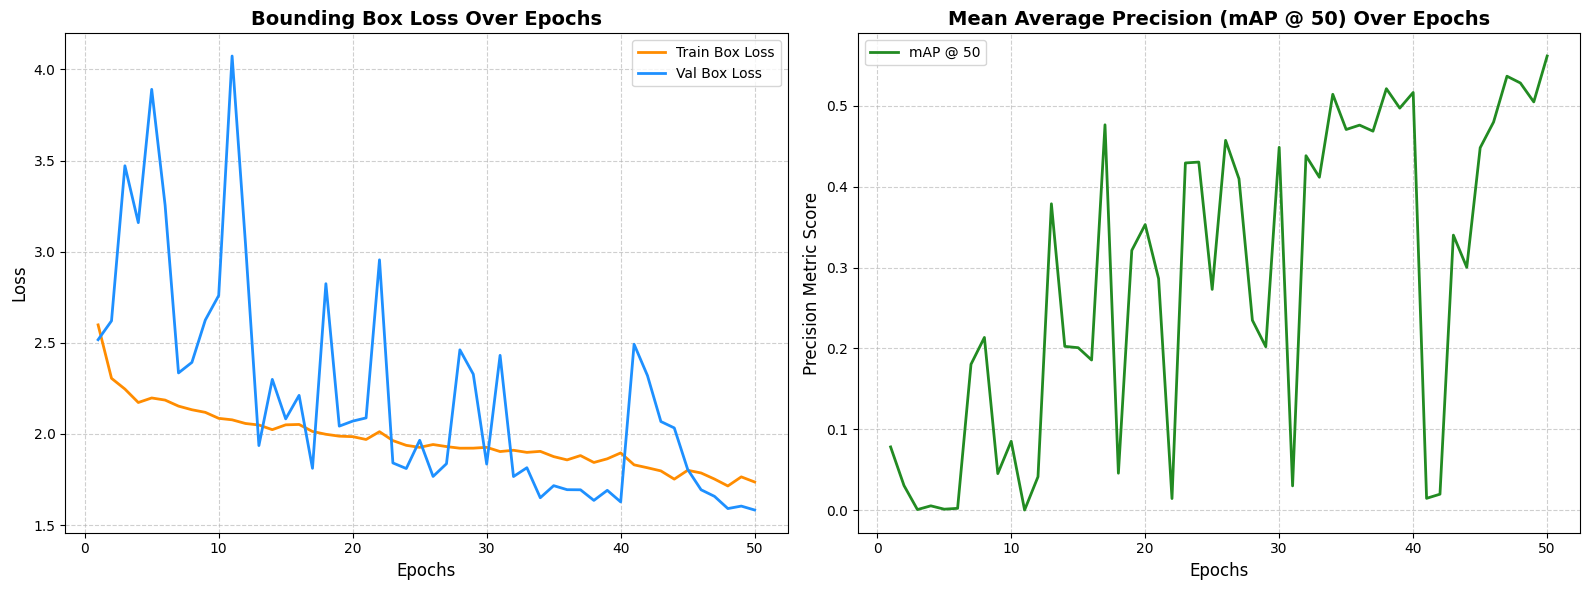

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to the auto-saved tracking data
results_csv_path = "/content/runs/detect/building_detector/results.csv"

if os.path.exists(results_csv_path):
    df = pd.read_csv(results_csv_path)
    # Strip any accidental whitespace from column headers
    df.columns = df.columns.str.strip()

    # Create side-by-side metric subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Train Box Loss vs Val Box Loss
    ax1.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='darkorange', linewidth=2)
    ax1.plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='dodgerblue', linewidth=2)
    ax1.set_title('Bounding Box Loss Over Epochs', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Plot 2: mAP@50 Curve
    ax2.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP @ 50', color='forestgreen', linewidth=2)
    ax2.set_title('Mean Average Precision (mAP @ 50) Over Epochs', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Precision Metric Score', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("Training log file not found! Make sure training finished successfully.")

| Metric | Your Value | What it means in plain English |
| :--- | :---: | :--- |
| **mAP@50** | **~0.562** | It measures the overall accuracy of your detector on a scale from 0 to 1. A score of 0.56 means that when checking predictions that overlap actual buildings by at least 50%. |
| **Precision** | **~0.714** | Out of all the bounding boxes the model *guessed* were buildings, roughly 71% of them were actually correct buildings. |
| **Recall** | **~0.545** | Out of all the actual buildings physically present in the satellite images, the model successfully detected 54% of them. High recall means the model doesn't overlook or miss real targets. |
| **F1 Score** | **~0.618** | The harmonic mean (balance score) between Precision and Recall. Because both metrics are evenly matched, your F1 Score indicates a highly stable detector that doesn't skew heavily toward over-predicting or under-predicting boundaries. |

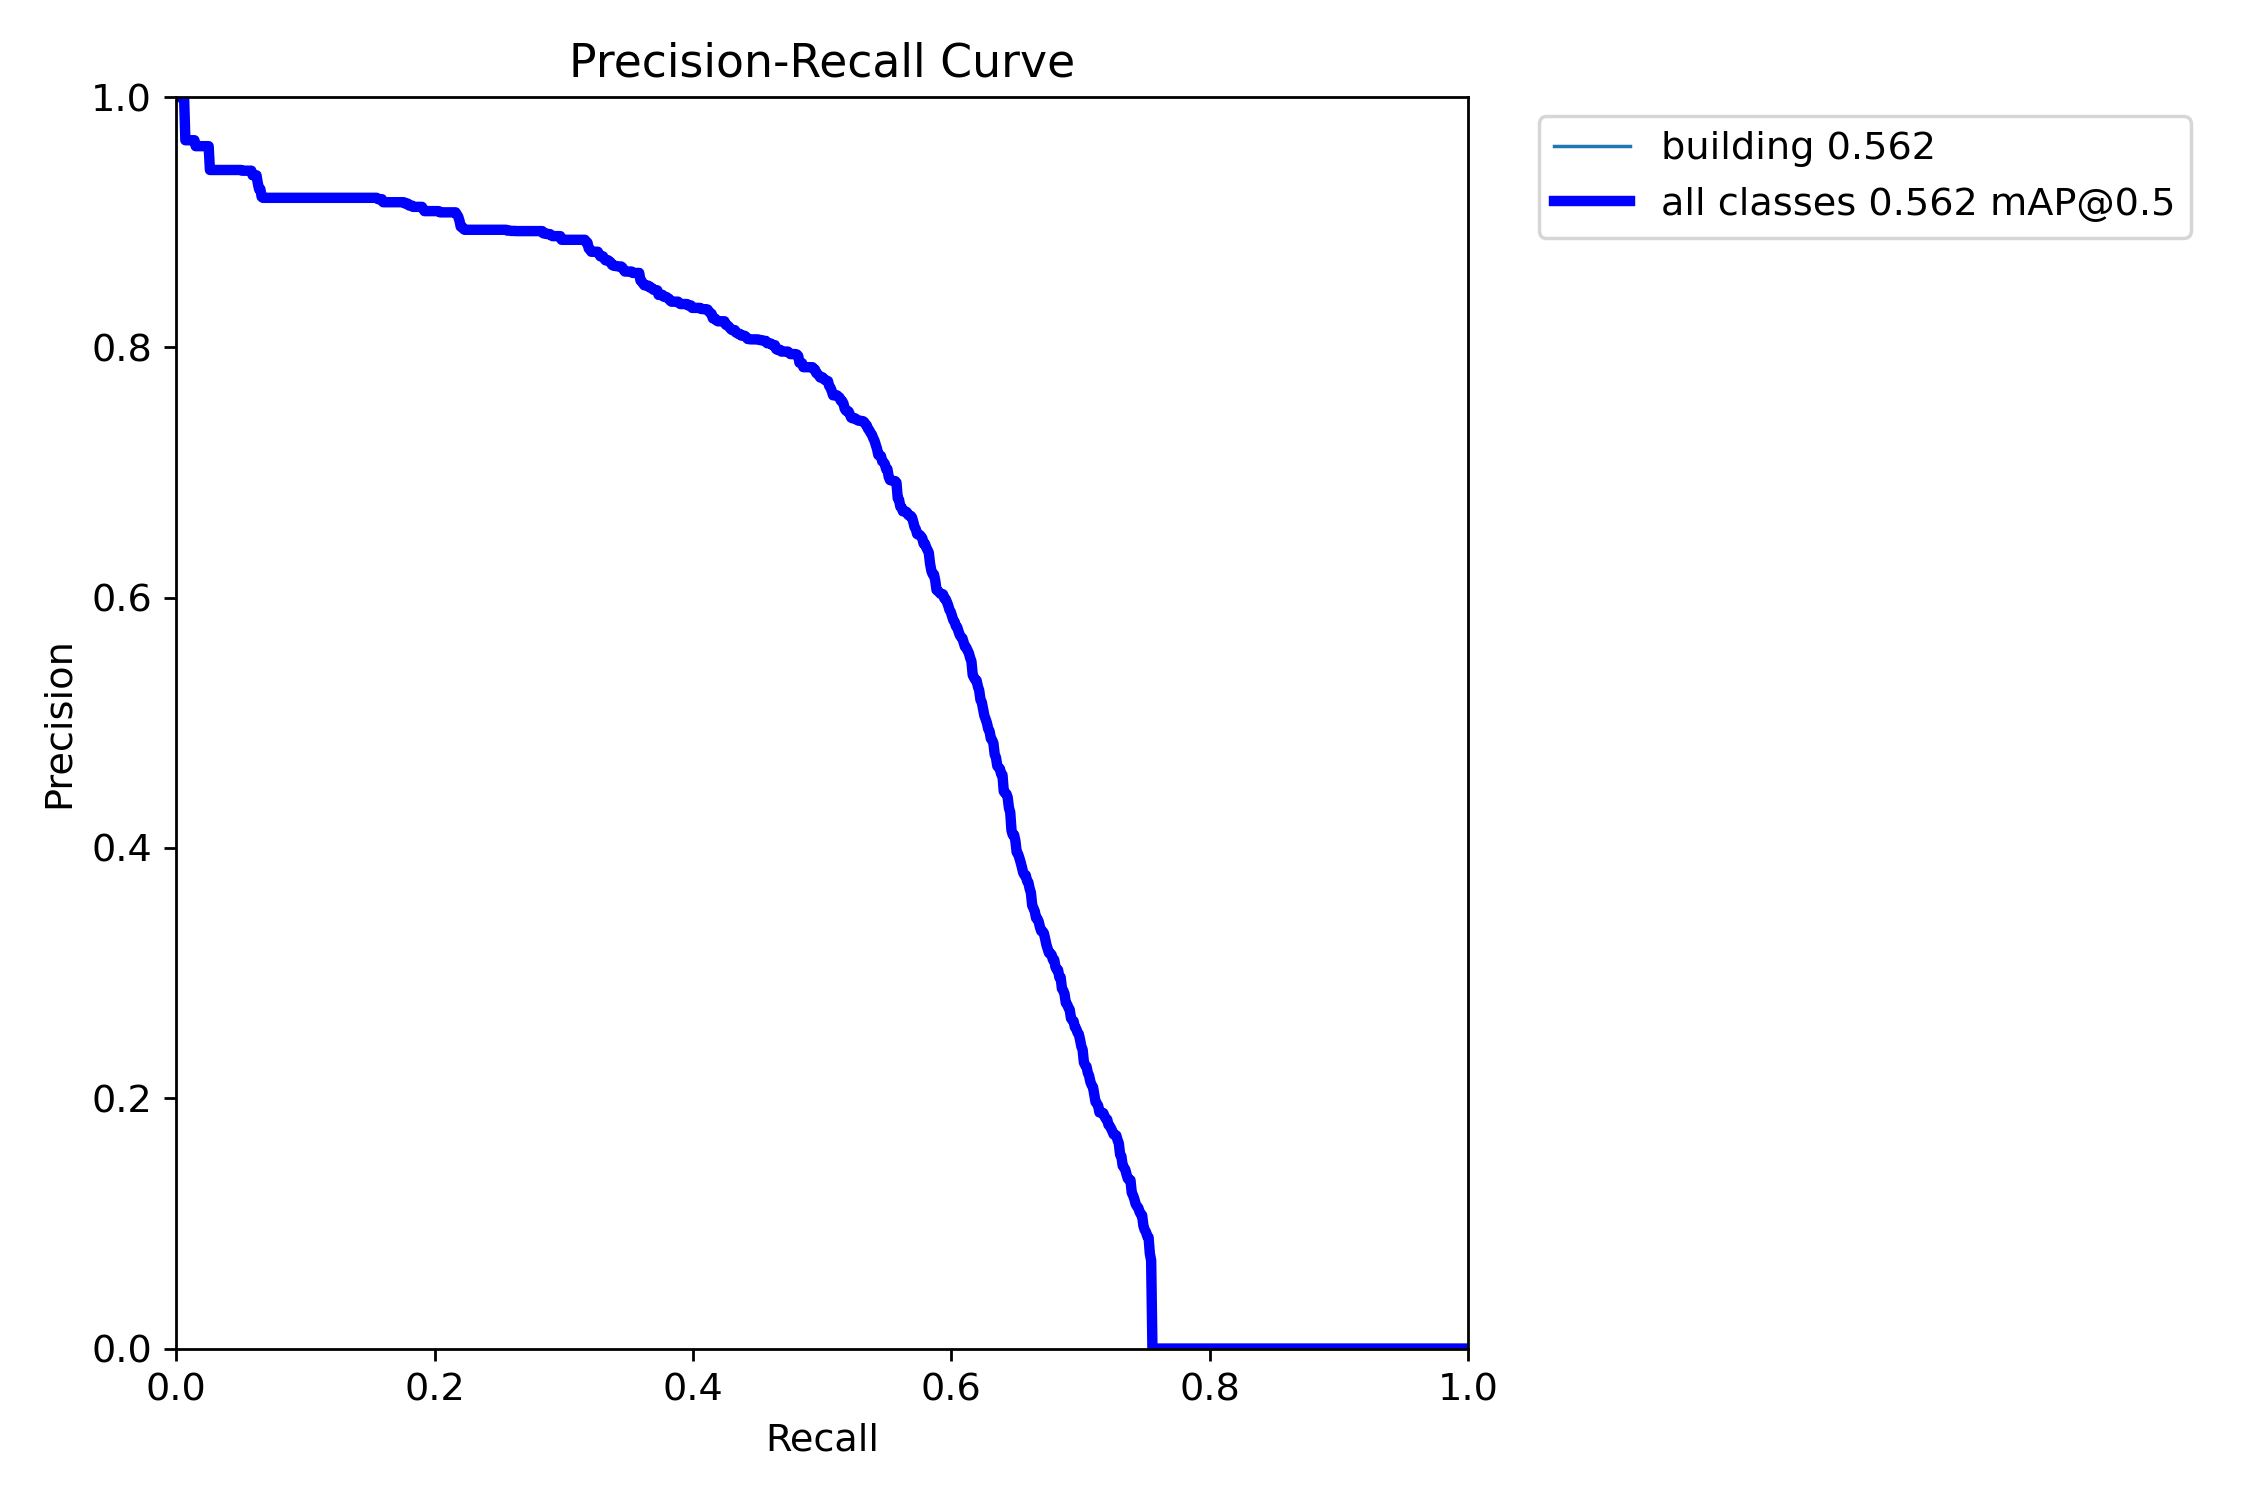

In [ ]:
from PIL import Image
Image.open("/content/runs/detect/building_detector/BoxPR_curve.png")


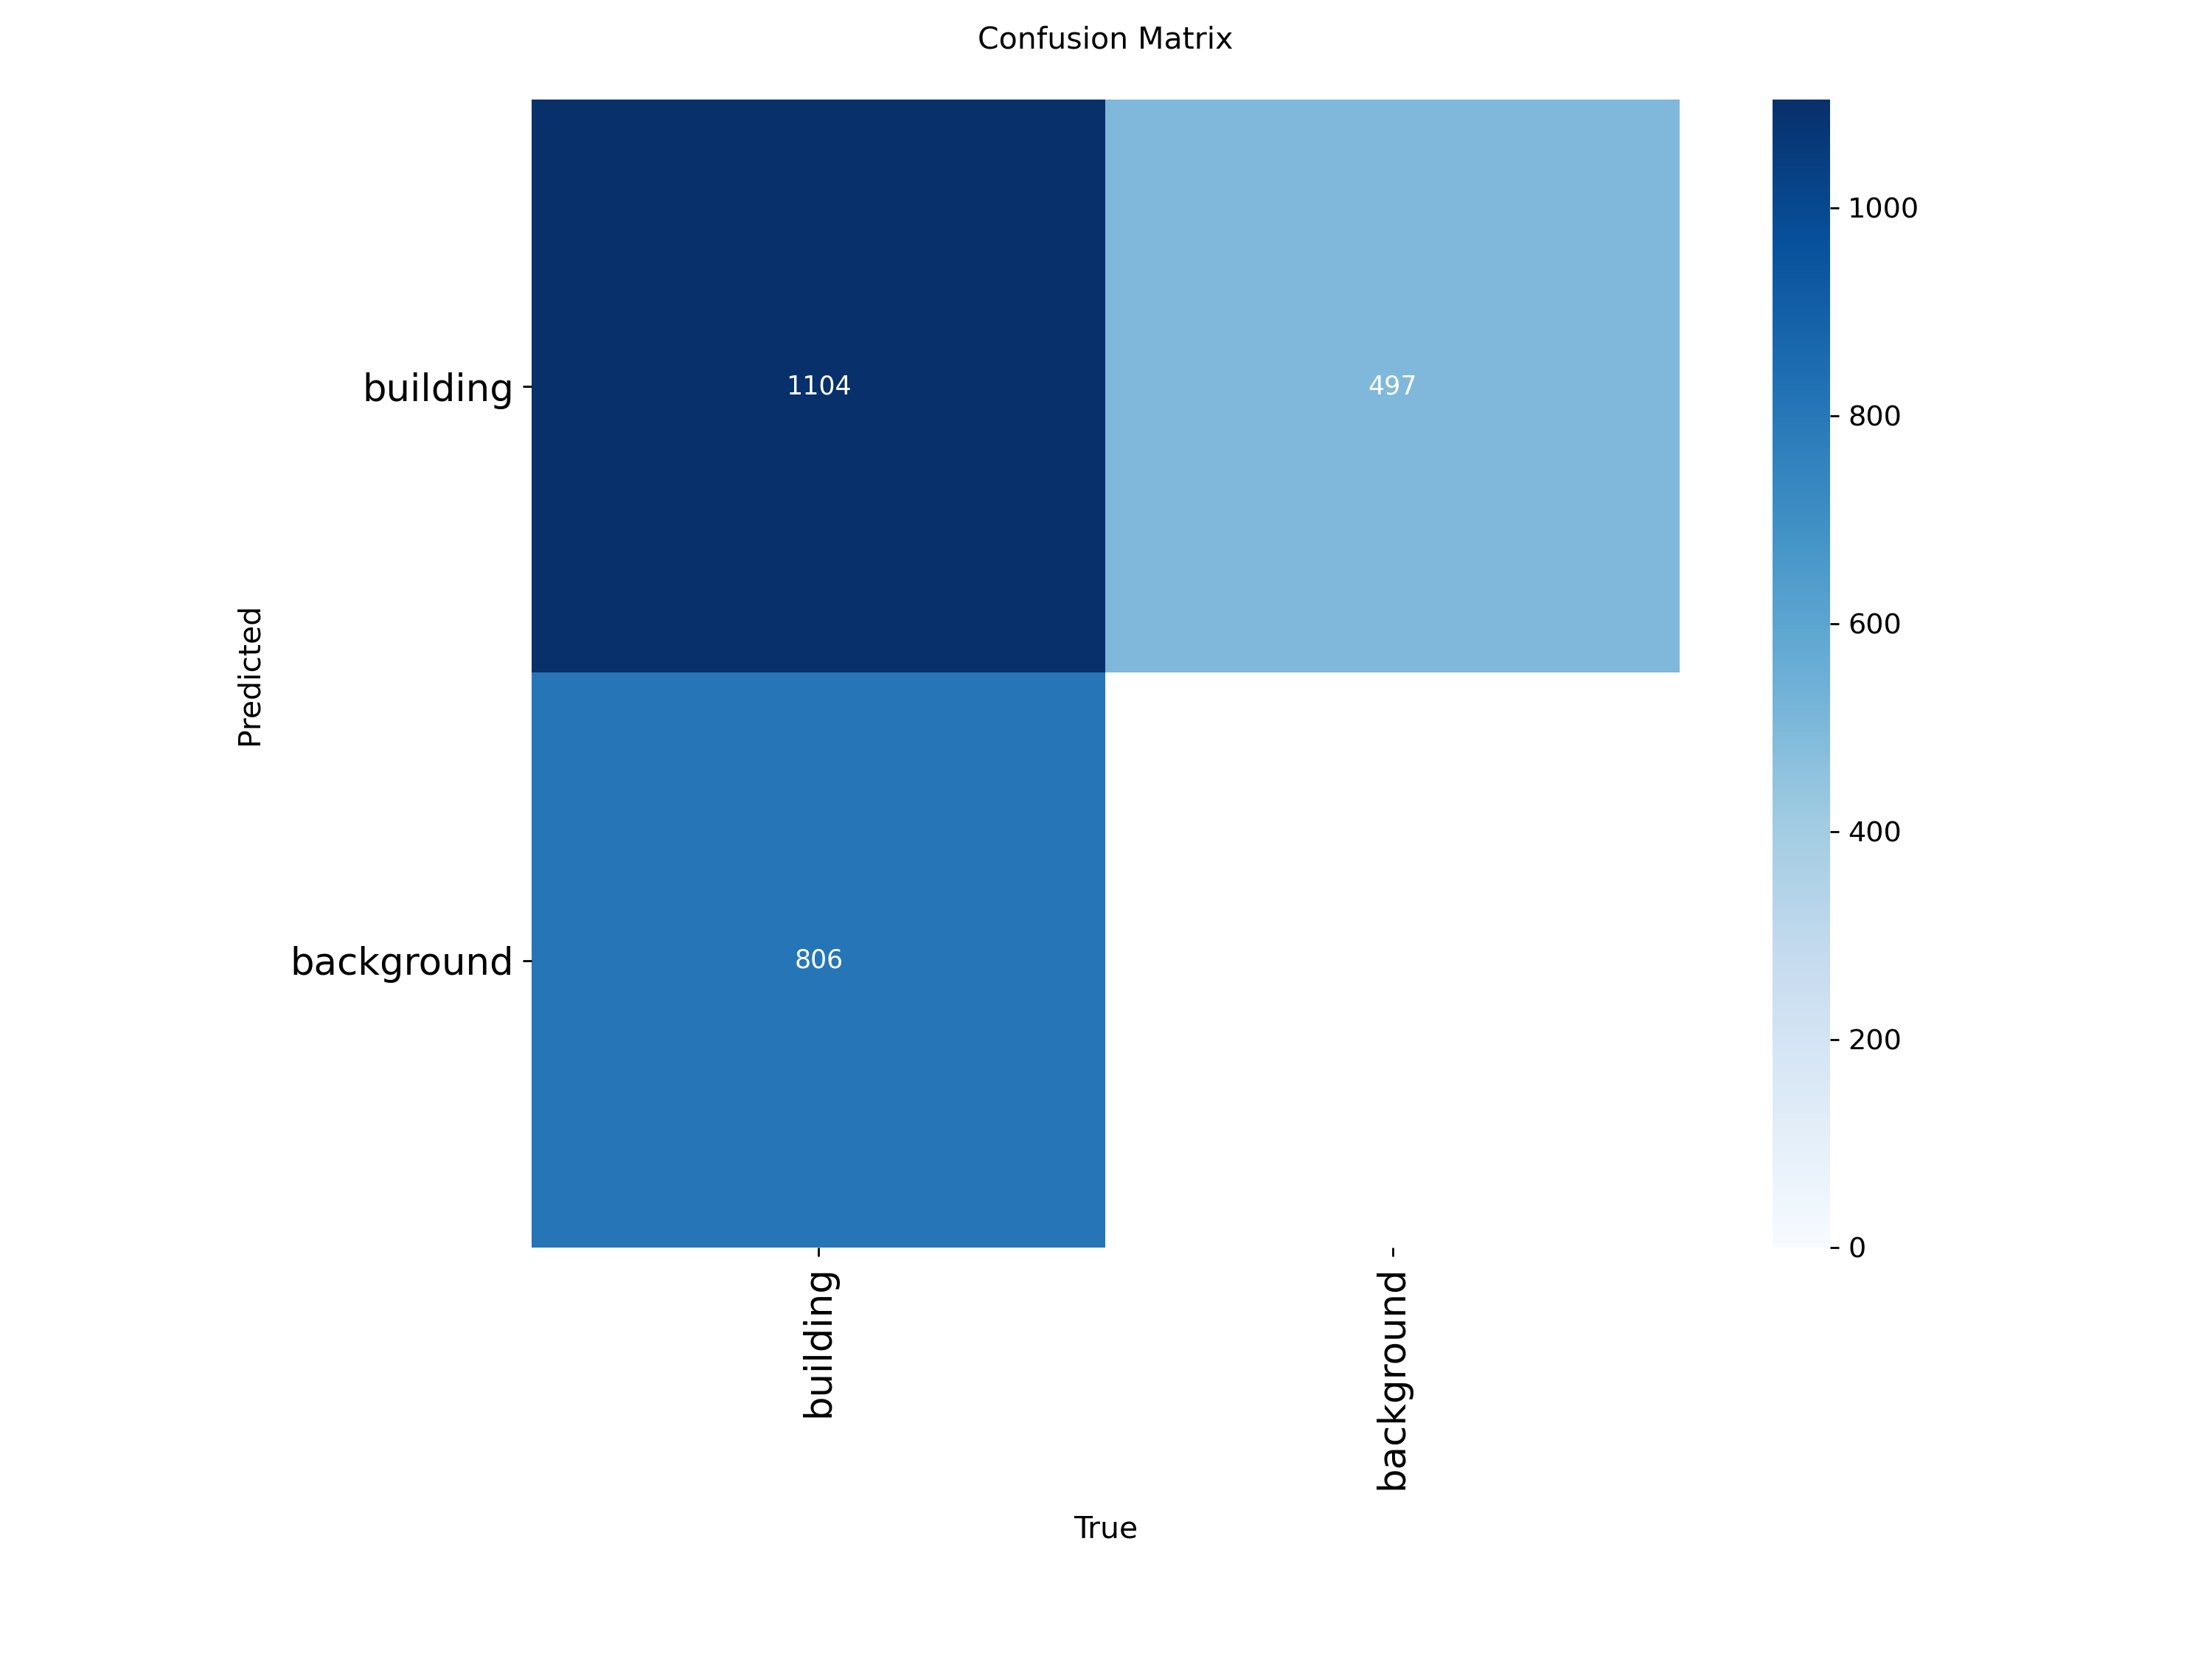

In [ ]:
Image.open("/content/runs/detect/building_detector/confusion_matrix.png")

Running validation inference on 10 test samples...


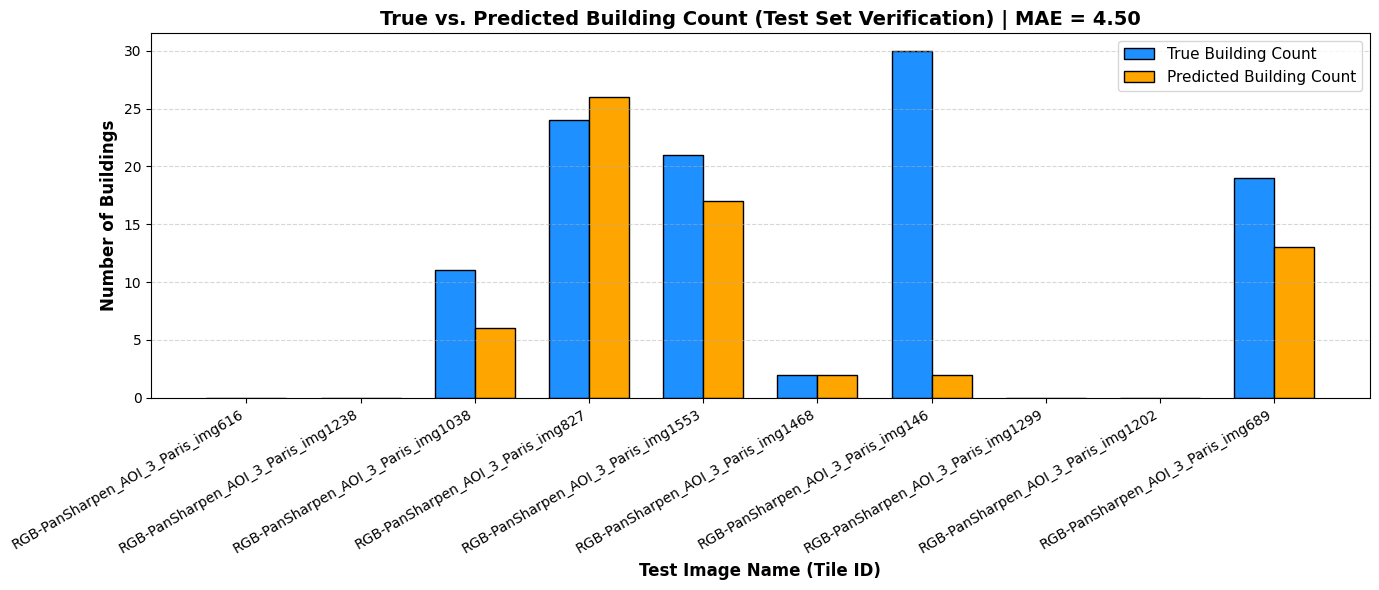


✅ Verification complete! Calculated Mean Absolute Error (MAE): 4.50


In [ ]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# 1. Initialize our highest performing T4 weights
# Note: Check if your run folder is named 'building_detector_gpu' or similar
model_path = "/content/runs/detect/building_detector/weights/best.pt"
model = YOLO(model_path)

test_img_dir = Path("/content/yolo_dataset/images/test")
test_lbl_dir = Path("/content/yolo_dataset/labels/test")

# Gather and sample exactly 10 test images
test_images = sorted([f for f in os.listdir(test_img_dir) if f.lower().endswith('.jpg')])
random.seed(42)  # For consistent selection
sampled_images = random.sample(test_images, 10)

img_names = []
true_counts = []
pred_counts = []

print("Running validation inference on 10 test samples...")
for img_name in sampled_images:
    img_path = test_img_dir / img_name
    lbl_path = test_lbl_dir / f"{img_path.stem}.txt"

    # Extract True Count from the text label file
    true_count = 0
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            lines = f.readlines()
            true_count = len([l for l in lines if l.strip()])

    # Extract Predicted Count via YOLOv8 model inference
    results = model.predict(img_path, verbose=False)
    pred_count = len(results[0].boxes)

    img_names.append(img_path.stem)
    true_counts.append(true_count)
    pred_counts.append(pred_count)

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(np.array(true_counts) - np.array(pred_counts)))

# Plot the comparative Bar Chart
x = np.arange(len(img_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, true_counts, width, label='True Building Count', color='dodgerblue', edgecolor='black')
ax.bar(x + width/2, pred_counts, width, label='Predicted Building Count', color='orange', edgecolor='black')

ax.set_xlabel('Test Image Name (Tile ID)', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Buildings', fontsize=12, fontweight='bold')
ax.set_title(f'True vs. Predicted Building Count (Test Set Verification) | MAE = {mae:.2f}', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(img_names, rotation=30, ha='right')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

print(f"\n✅ Verification complete! Calculated Mean Absolute Error (MAE): {mae:.2f}")


🚀 Commencing Final Pipeline Demonstrations on 3 Test Split targets...



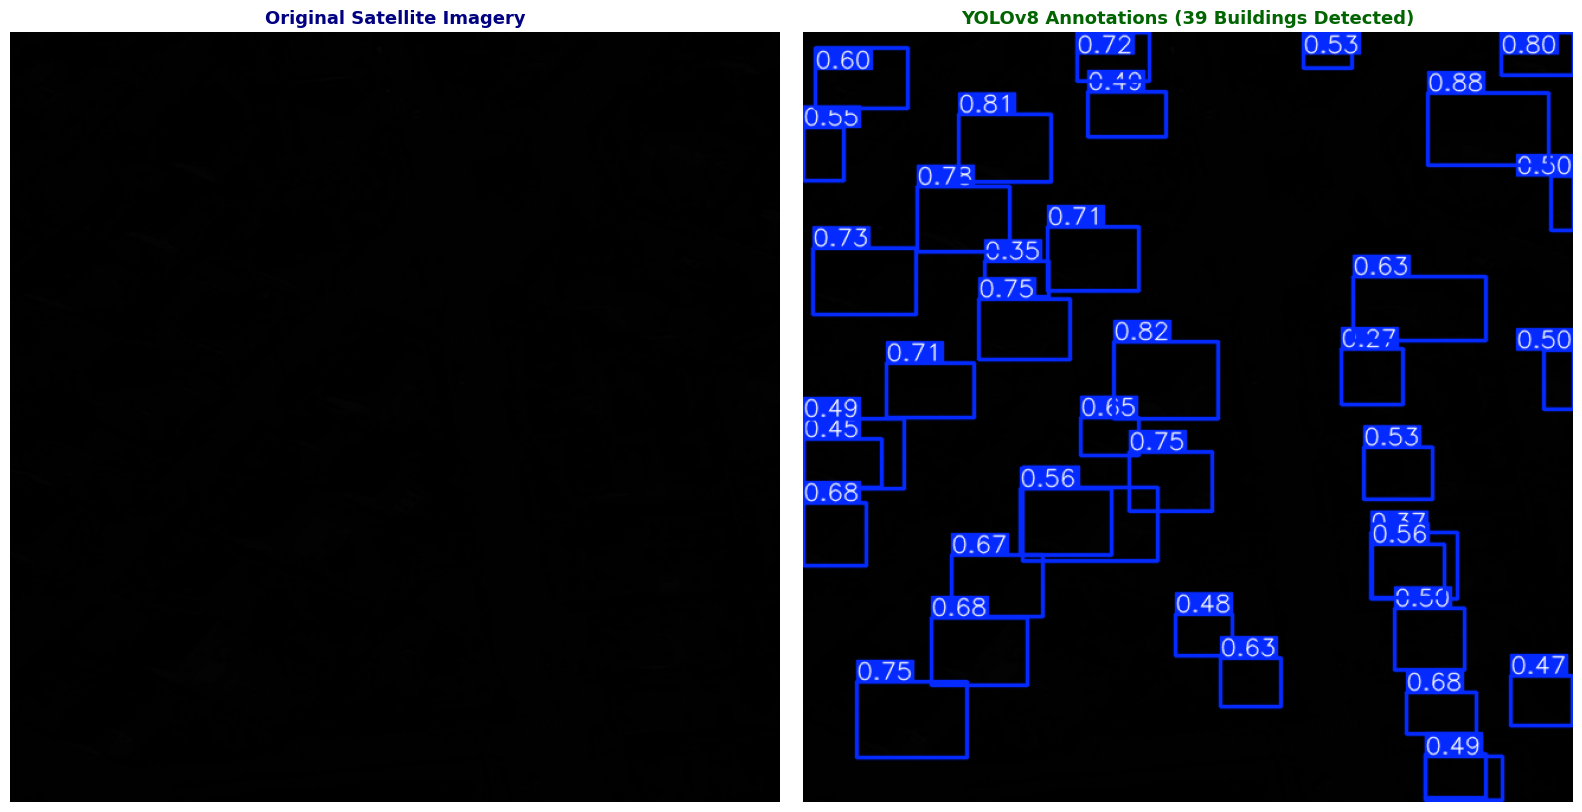

Image: RGB-PanSharpen_AOI_3_Paris_img1010.jpg
Buildings detected : 39
Avg confidence : 0.60
Processing time : 181.4 ms
----------------------------------------


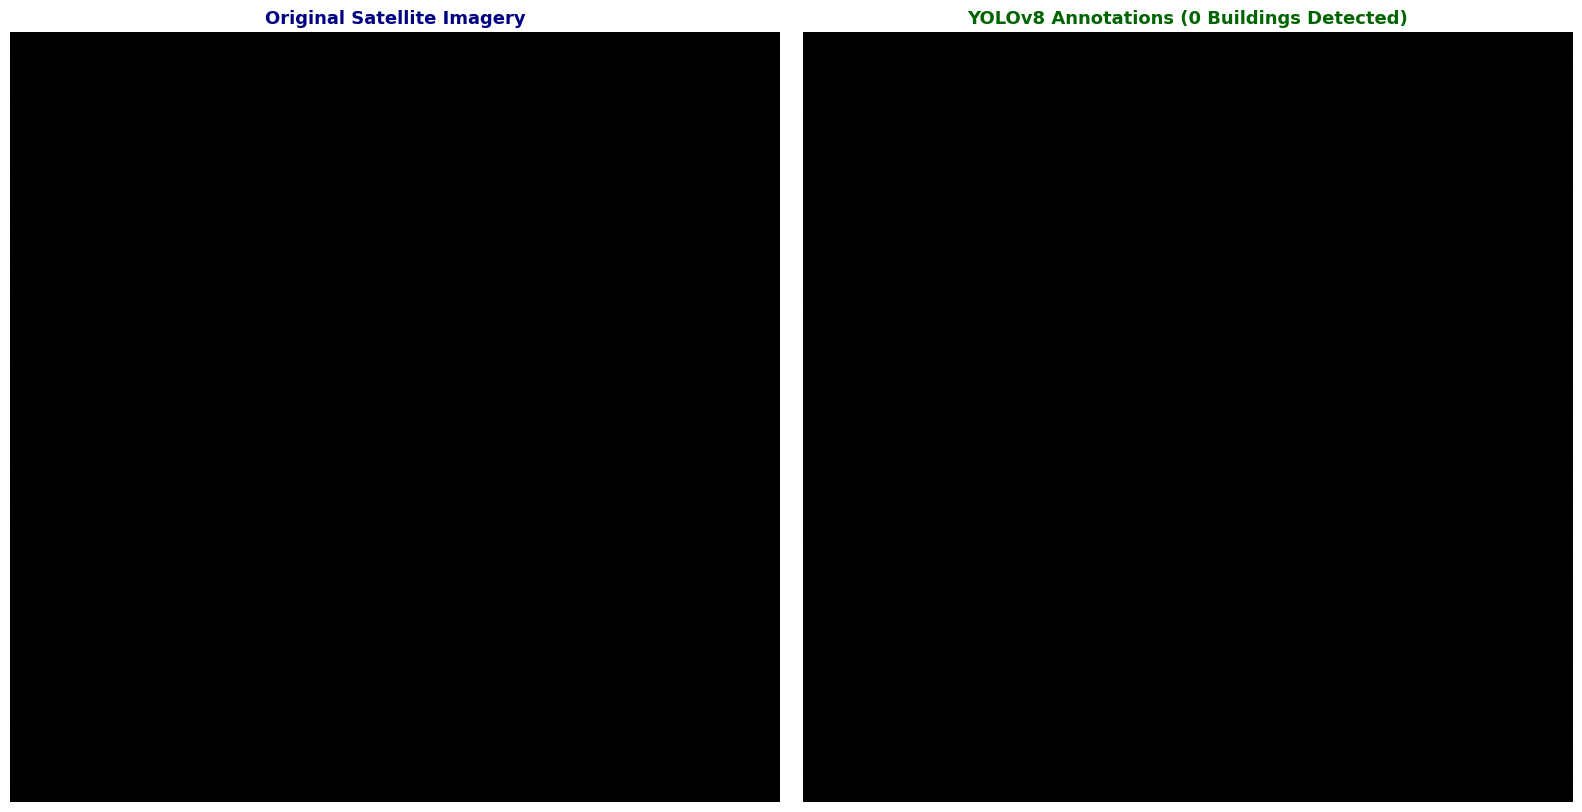

Image: RGB-PanSharpen_AOI_3_Paris_img1034.jpg
Buildings detected : 0
Avg confidence : 0.00
Processing time : 190.4 ms
----------------------------------------


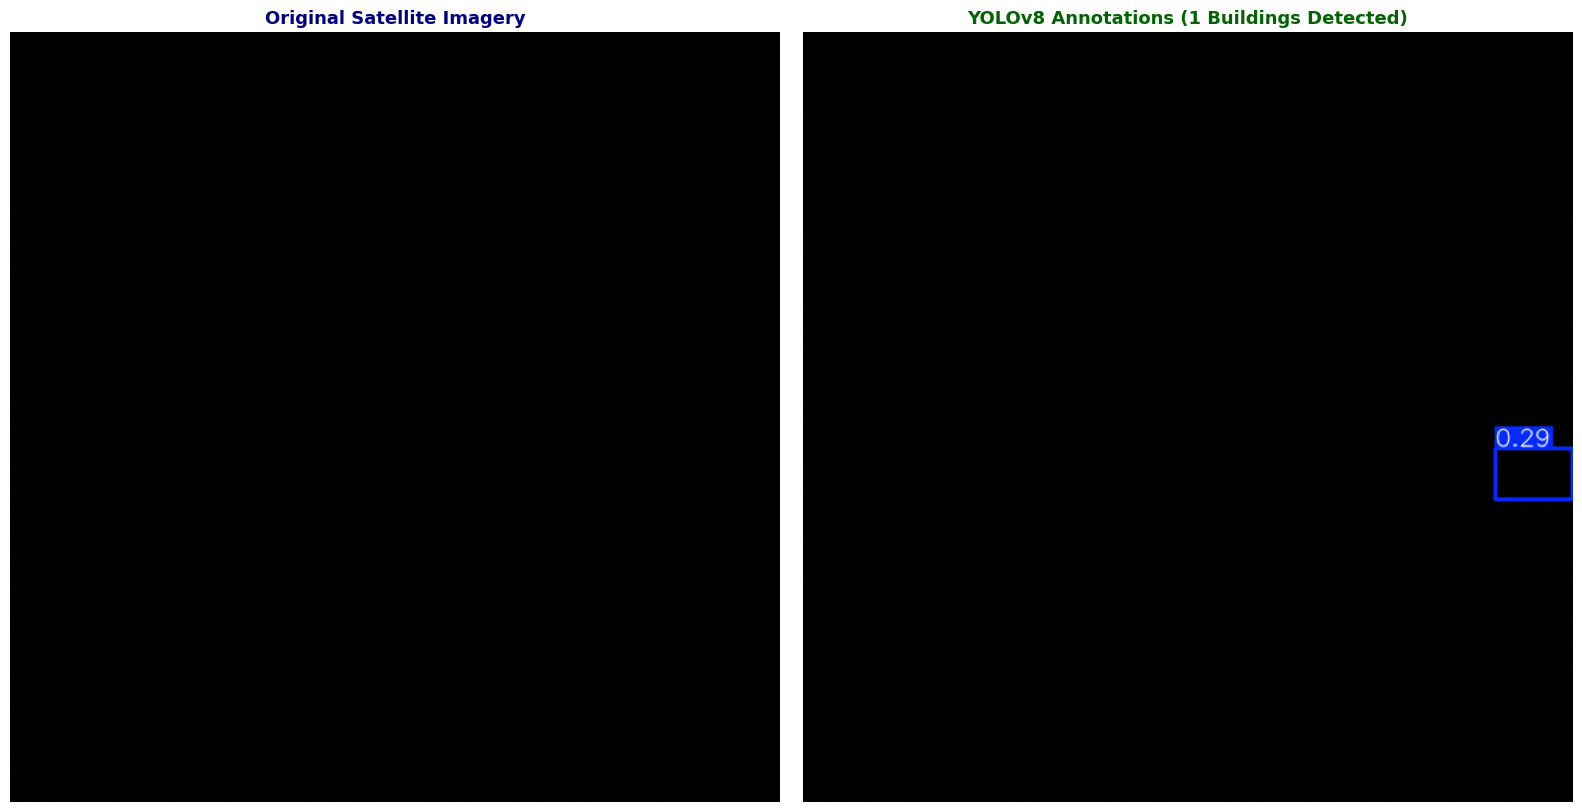

Image: RGB-PanSharpen_AOI_3_Paris_img1036.jpg
Buildings detected : 1
Avg confidence : 0.29
Processing time : 187.2 ms
----------------------------------------


In [ ]:
import os
import time
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

def end_to_end_prediction_pipeline(image_path, model_path):
    """
    Runs end-to-end building detection inference, displays original vs annotated plots,
    and prints detailed execution runtime performance metrics.
    """
    # Start tracking time immediately
    start_time = time.time()

    # 1. Load weights and run inference
    model = YOLO(model_path)
    results = model.predict(image_path, verbose=False)[0]

    # Calculate inference processing time delta in milliseconds
    processing_time_ms = (time.time() - start_time) * 1000

    # 2. Extract metrics
    num_buildings = len(results.boxes)

    if num_buildings > 0:
        avg_confidence = results.boxes.conf.cpu().numpy().mean()
    else:
        avg_confidence = 0.00

    # 3. Handle image arrays for side-by-side plotting
    # Original image (Convert BGR to RGB)
    orig_img = cv2.imread(str(image_path))
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

    # Annotated image array generated automatically by YOLOv8 plot() function
    annotated_img = results.plot(line_width=2, labels=False) # labels=False keeps it clean for dense rooftops
    annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    # 4. Generate the Side-by-Side Figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    ax1.imshow(orig_img)
    ax1.set_title("Original Satellite Imagery", fontsize=13, fontweight='bold', color='navy')
    ax1.axis('off')

    ax2.imshow(annotated_img)
    ax2.set_title(f"YOLOv8 Annotations ({num_buildings} Buildings Detected)", fontsize=13, fontweight='bold', color='darkgreen')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

    # 5. Print out the exact summary format requested by assignment instructions
    print(f"Image: {Path(image_path).name}")
    print(f"Buildings detected : {num_buildings}")
    print(f"Avg confidence : {avg_confidence:.2f}")
    print(f"Processing time : {processing_time_ms:.1f} ms")
    print("-" * 40)

# ==========================================
# TEST EXECUTION ON 3 DIFFERENT IMAGES
# ==========================================
test_dir = Path("/content/yolo_dataset/images/test")
trained_weights = "/content/runs/detect/building_detector/weights/best.pt"

# Fetch three files from your verified test folder
test_pool = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.jpg')])[:3]

print("\n🚀 Commencing Final Pipeline Demonstrations on 3 Test Split targets...\n")
for target_file in test_pool:
    full_target_path = test_dir / target_file
    end_to_end_prediction_pipeline(full_target_path, trained_weights)